In [1]:
#import libraries
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score,GridSearchCV
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [5]:
from google.colab import files
uploaded = files.upload()

Saving heart.csv to heart.csv


In [6]:
data = pd.read_csv("heart.csv")
data

,AGE_50,MD_50,SBP_50,DBP_50,HT_50,WT_50,CHOL_50,SES,CL_STATUS,MD_62,SBP_62,DBP_62,CHOL_62,WT_62,IHD_DX,DEATH
0,42,1,110,65,64,147,291,2,8,4,120,78,271,146,2,1
1,53,1,130,72,69,167,278,1,6,2,122,68,250,165,9,1
2,53,2,120,90,70,222,342,4,8,1,132,90,304,223,2,1
3,48,4,120,80,72,229,239,4,8,2,118,68,209,227,3,1
4,53,3,118,74,66,134,243,3,8,5,118,56,261,138,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,50,1,115,80,66,148,300,2,8,1,115,65,273,152,0,0
196,23,1,110,70,69,137,120,3,8,2,112,76,198,153,0,0
197,20,3,130,80,66,150,210,5,0,1,130,85,274,158,0,0
198,46,3,140,84,66,138,130,4,6,2,148,88,160,157,0,0


In [7]:
data.head()

,AGE_50,MD_50,SBP_50,DBP_50,HT_50,WT_50,CHOL_50,SES,CL_STATUS,MD_62,SBP_62,DBP_62,CHOL_62,WT_62,IHD_DX,DEATH
0,42,1,110,65,64,147,291,2,8,4,120,78,271,146,2,1
1,53,1,130,72,69,167,278,1,6,2,122,68,250,165,9,1
2,53,2,120,90,70,222,342,4,8,1,132,90,304,223,2,1
3,48,4,120,80,72,229,239,4,8,2,118,68,209,227,3,1
4,53,3,118,74,66,134,243,3,8,5,118,56,261,138,2,1


In [8]:
data.tail()

,AGE_50,MD_50,SBP_50,DBP_50,HT_50,WT_50,CHOL_50,SES,CL_STATUS,MD_62,SBP_62,DBP_62,CHOL_62,WT_62,IHD_DX,DEATH
195,50,1,115,80,66,148,300,2,8,1,115,65,273,152,0,0
196,23,1,110,70,69,137,120,3,8,2,112,76,198,153,0,0
197,20,3,130,80,66,150,210,5,0,1,130,85,274,158,0,0
198,46,3,140,84,66,138,130,4,6,2,148,88,160,157,0,0
199,36,1,100,70,70,157,260,3,8,3,120,86,251,152,0,0


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 16 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   AGE_50     200 non-null    int64
 1   MD_50      200 non-null    int64
 2   SBP_50     200 non-null    int64
 3   DBP_50     200 non-null    int64
 4   HT_50      200 non-null    int64
 5   WT_50      200 non-null    int64
 6   CHOL_50    200 non-null    int64
 7   SES        200 non-null    int64
 8   CL_STATUS  200 non-null    int64
 9   MD_62      200 non-null    int64
 10  SBP_62     200 non-null    int64
 11  DBP_62     200 non-null    int64
 12  CHOL_62    200 non-null    int64
 13  WT_62      200 non-null    int64
 14  IHD_DX     200 non-null    int64
 15  DEATH      200 non-null    int64
dtypes: int64(16)
memory usage: 25.1 KB


In [10]:
data.describe()

,AGE_50,MD_50,SBP_50,DBP_50,HT_50,WT_50,CHOL_50,SES,CL_STATUS,MD_62,SBP_62,DBP_62,CHOL_62,WT_62,IHD_DX,DEATH
count,200.00000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,46.06500,2.360000,124.700000,83.380000,68.160000,168.075000,258.105000,2.915000,7.650000,2.315000,141.480000,84.820000,254.070000,167.375000,1.410000,0.320000
std,10.81274,1.017633,18.114654,11.000484,2.768161,26.639589,55.524126,1.069342,1.119718,1.197055,24.656833,12.808116,46.509686,27.516178,2.464196,0.467647
min,20.00000,1.000000,88.000000,38.000000,61.000000,109.000000,120.000000,1.000000,0.000000,1.000000,70.000000,56.000000,139.000000,108.000000,0.000000,0.000000
25%,38.00000,1.000000,110.000000,78.000000,66.000000,147.000000,220.000000,2.000000,8.000000,1.000000,125.000000,76.000000,222.750000,148.750000,0.000000,0.000000
50%,47.00000,2.000000,120.000000,80.000000,68.000000,165.000000,250.000000,3.000000,8.000000,2.000000,138.000000,83.000000,251.500000,165.500000,0.000000,0.000000
75%,54.00000,3.000000,130.000000,90.000000,70.000000,189.000000,295.000000,3.000000,8.000000,3.000000,155.000000,90.000000,283.250000,187.000000,2.000000,1.000000
max,69.00000,4.000000,210.000000,140.000000,75.000000,245.000000,535.000000,5.000000,8.000000,5.000000,230.000000,125.000000,368.000000,246.000000,9.000000,1.000000


In [11]:
data.columns

Index(['AGE_50', 'MD_50', 'SBP_50', 'DBP_50', 'HT_50', 'WT_50', 'CHOL_50',
       'SES', 'CL_STATUS', 'MD_62', 'SBP_62', 'DBP_62', 'CHOL_62', 'WT_62',
       'IHD_DX', 'DEATH'],
      dtype='object')

In [12]:
X = data.drop(columns=["DEATH"])
y = data["DEATH"]

In [13]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.3, random_state=42)

In [14]:
dt_param_grid = {'max_depth': [3, 4, 5, 6, None],'min_samples_split': [2, 5, 10, 15],'min_samples_leaf': [1, 3, 5, 7],'ccp_alpha': [0.0, 0.005, 0.01, 0.02]}
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42),dt_param_grid,cv=5,scoring='accuracy',n_jobs=-1)

In [15]:
dt_grid.fit(X_train, y_train)
print("Best Decision Tree Params:", dt_grid.best_params_)
print("Best Decision Tree CV Score:", dt_grid.best_score_)

Best Decision Tree Params: {'ccp_alpha': 0.02, 'max_depth': 4, 'min_samples_leaf': 7, 'min_samples_split': 2}
Best Decision Tree CV Score: 0.7857142857142858


In [16]:
# Train best Decision Tree on full train set
dt_best = dt_grid.best_estimator_
dt_best.fit(X_train, y_train)

DecisionTreeClassifier(ccp_alpha=0.02, max_depth=4, min_samples_leaf=7,
                       random_state=42)

In [17]:
print("Decision Tree Train Accuracy:", dt_best.score(X_train, y_train))
print("Decision Tree Test Accuracy :", dt_best.score(X_test, y_test))

Decision Tree Train Accuracy: 0.7928571428571428
Decision Tree Test Accuracy : 0.6833333333333333


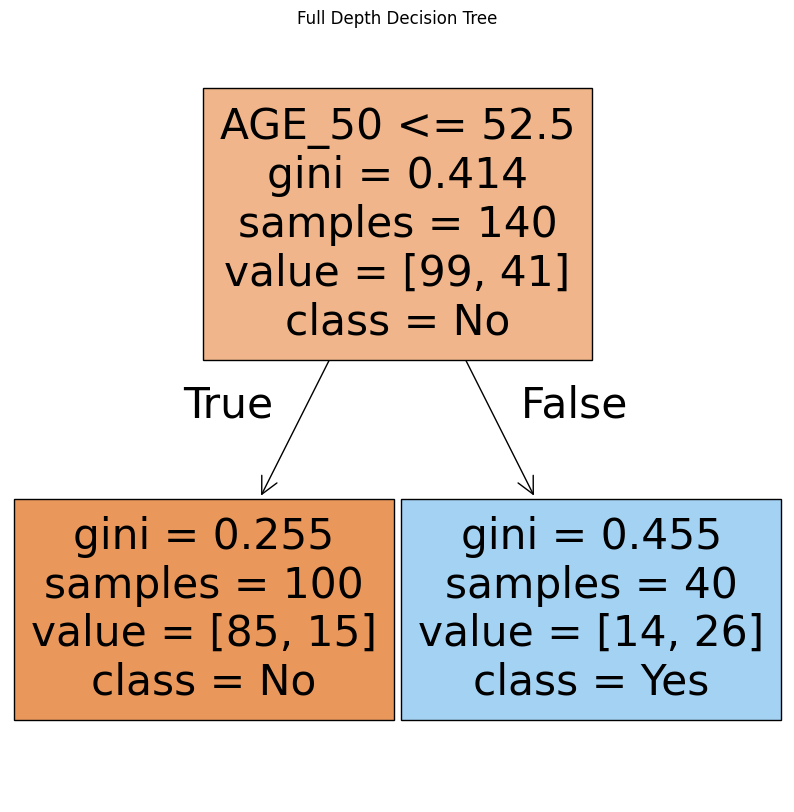

In [18]:
# Visualize the tree
plt.figure(figsize=(10, 10))
plot_tree(dt_best, feature_names=X.columns, class_names=["No", "Yes"], filled=True)
plt.title("Full Depth Decision Tree")
plt.show()

In [19]:
print("Decision Tree (Full Depth) Accuracy - Train:", dt_best.score(X_train, y_train))
print("Decision Tree (Full Depth) Accuracy - Test :", dt_best.score(X_test, y_test))

Decision Tree (Full Depth) Accuracy - Train: 0.7928571428571428
Decision Tree (Full Depth) Accuracy - Test : 0.6833333333333333


In [23]:
#  TRAIN RANDOM FOREST & COMPARE ACCURACY
random = RandomForestClassifier(n_estimators=100, random_state=42,max_features = "log2",max_depth = 7,min_samples_split = 20)
random.fit(X_train, y_train)


RandomForestClassifier(max_depth=7, max_features='log2', min_samples_split=20,
                       random_state=42)

In [25]:
print("Random Forest Train Accuracy:", random.score(X_train, y_train))
print("Random Forest Test Accuracy :", random.score(X_test, y_test))

Random Forest Train Accuracy: 0.8714285714285714
Random Forest Test Accuracy : 0.6666666666666666


In [26]:
# FEATURE IMPORTANCE (RANDOM FOREST)
importances = random.feature_importances_
indices = np.argsort(importances)[::-1]

In [27]:
print("\nFeature ranking:")
for i in range(X.shape[1]):
    print(f"{X.columns[indices[i]]}: {importances[indices[i]]:.4f}")


Feature ranking:
AGE_50: 0.2933
WT_62: 0.1175
WT_50: 0.1084
CHOL_62: 0.1023
MD_62: 0.0616
HT_50: 0.0511
SBP_62: 0.0435
DBP_50: 0.0409
SBP_50: 0.0386
CHOL_50: 0.0374
DBP_62: 0.0301
IHD_DX: 0.0264
MD_50: 0.0262
SES: 0.0124
CL_STATUS: 0.0103


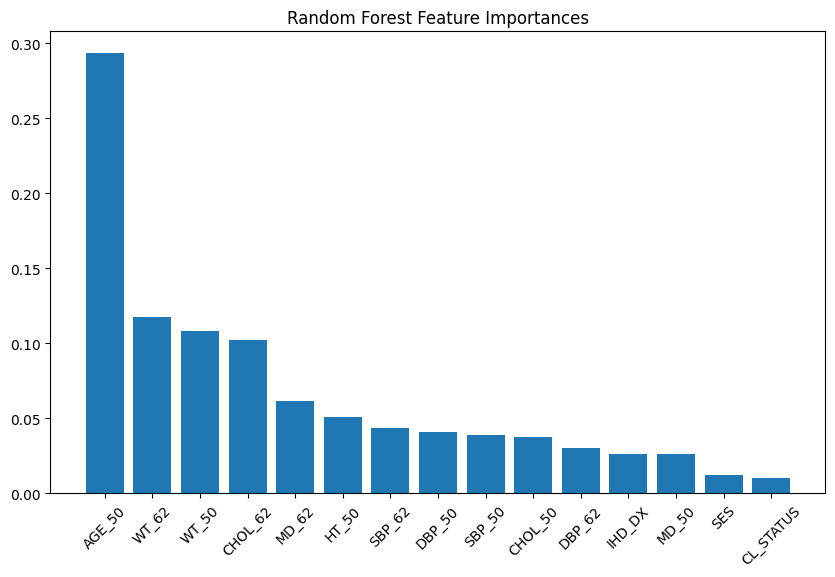

In [28]:
# Plot Feature Importance
plt.figure(figsize=(10, 6))
plt.bar(range(X.shape[1]), importances[indices])
plt.xticks(range(X.shape[1]), [X.columns[i] for i in indices], rotation=45)
plt.title("Random Forest Feature Importances")
plt.show()

In [29]:
# 7. CROSS-VALIDATION EVALUATION
dt_cv_scores = cross_val_score(dt_best, X, y, cv=5)
rf_cv_scores = cross_val_score(random, X, y, cv=5)

In [30]:
print("\nDecision Tree (Limited Depth) CV Accuracy:", dt_cv_scores.mean())
print("Random Forest CV Accuracy:", rf_cv_scores.mean())


Decision Tree (Limited Depth) CV Accuracy: 0.735
Random Forest CV Accuracy: 0.68
